(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


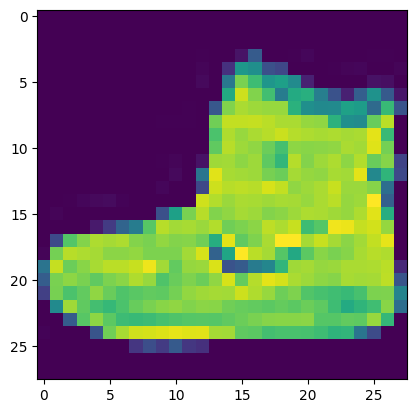

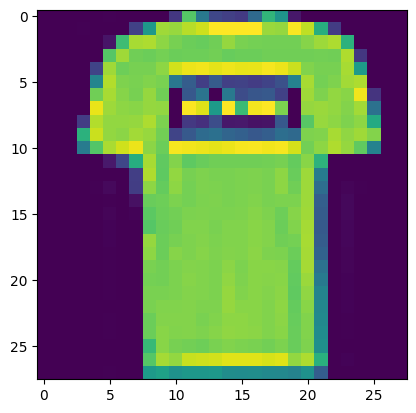

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 - 10s - 7ms/step - accuracy: 0.8171 - loss: 0.5067 - val_accuracy: 0.8535 - val_loss: 0.4148
Epoch 2/5
1500/1500 - 8s - 5ms/step - accuracy: 0.8619 - loss: 0.3789 - val_accuracy: 0.8554 - val_loss: 0.4014
Epoch 3/5
1500/1500 - 9s - 6ms/step - accuracy: 0.8741 - loss: 0.3403 - val_accuracy: 0.8743 - val_loss: 0.3525
Epoch 4/5
1500/1500 - 9s - 6ms/step - accuracy: 0.8825 - loss: 0.3158 - val_accuracy: 0.8706 - val_loss: 0.3521
Epoch 5/5
1500/1500 - 8s - 5ms/step - accuracy: 0.8897 - loss: 0.2969 - val_accuracy: 0.8652 - val_loss: 0.3669
Epoch 1/5
1500/1500 - 10s - 7ms/step - accuracy: 0.8024 - loss: 0.8369 - val_accuracy: 0.8447 - val_loss: 0.5726
Epoch 2/5
1500/1500 - 10s - 7ms/step - accuracy: 0.8415 - loss: 0.5547 - val_accuracy: 0.8322 - val_loss: 0.5545
Epoch 3/5
1500/1500 - 10s - 7ms/step - accuracy: 0.8531 - loss: 0.4921 - val_accuracy: 0.8481 - val_loss: 0.4850
Epoch 4/5
1500/1500 - 10s - 7ms/step - accuracy: 0.8590 - loss: 0.4656 - val_accuracy: 0.8471 - val_

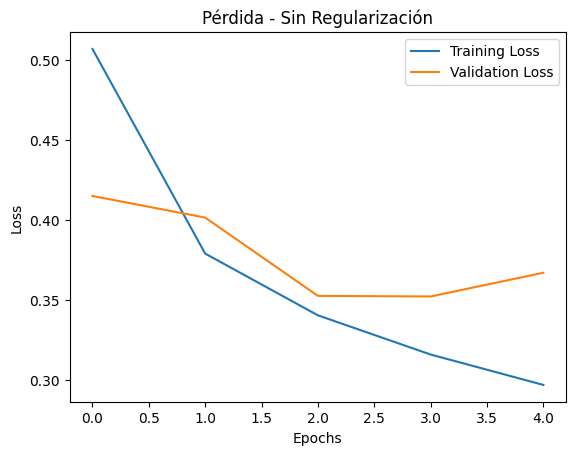

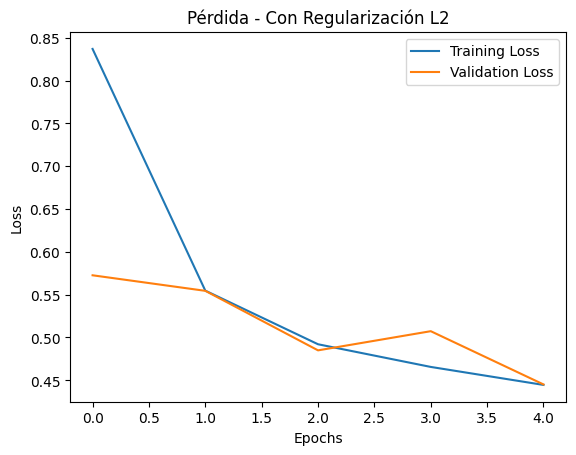

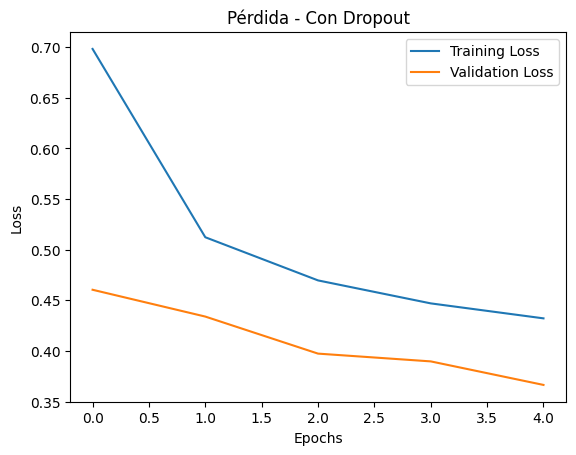


Ejemplo de salida antes de aplicar softmax:
[-8.637171  -5.527055  -7.732962  -6.7123566 -9.413216   1.6087353
 -5.9961715  5.499301  -1.4313089 10.28113  ]

Ejemplo de salida después de aplicar softmax:
[6.0281566e-09 1.3517325e-07 1.4889414e-08 4.1316234e-08 2.7742943e-09
 1.6979501e-04 8.4558209e-08 8.3095254e-03 8.1217695e-06 9.9151230e-01]
Predicción: 9, Real: 9
Predicción: 0, Real: 0
Predicción: 3, Real: 0
Predicción: 3, Real: 3
Predicción: 3, Real: 0
Predicción: 2, Real: 2
Predicción: 7, Real: 7
Predicción: 4, Real: 2
Predicción: 5, Real: 5
Predicción: 5, Real: 5


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.nn import softmax
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

plt.imshow(x_train[0])
plt.show()

plt.imshow(x_train[1])
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

class AccuracyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.95:
            print("Se alcanzo el máximo de precision")
            self.model.stop_training = True

def train(with_regularization=False, with_dropout=False):
    myCallback = AccuracyCallback()

    model = tf.keras.models.Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    if with_regularization:
        model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    else:
        model.add(Dense(512, activation='relu'))

    if with_dropout:
        model.add(Dropout(0.5))

    if with_regularization:
        model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    else:
        model.add(Dense(256, activation='relu'))

    if with_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))

    model.add(Dense(10))

    model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=5, callbacks=[myCallback], validation_split=0.2, verbose="auto")

    return history.history, model


history_no_reg, model_no_reg = train()

history_l2_reg, model_l2_reg = train(with_regularization=True)

history_dropout, model_dropout = train(with_dropout=True)

def plot_loss(history, title):
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(history_no_reg, 'Perdida sin Regularizacion')
plot_loss(history_l2_reg, 'Perdida con L2')
plot_loss(history_dropout, 'Perdida con Dropout')


